# Numerical Data Science Study Project: Weather Data Analysis

*Public portfolio version of a study project. Personal data and internal course material have been removed.*

This notebook analyses weather data from the **SAM (Samedan)** weather station. The project was completed as part of the course *Numerische Grundlagen der Data Science* in the BSc Applied Digital Life Sciences at *Zürcher Hochschule für Angewandte Wissenschaften (ZHAW)*.

For the assignment, approximately 30% of the original dataset values were intentionally removed by the lecturer. The main objective of the project was to reconstruct the missing values using suitable interpolation methods and to evaluate how well different numerical approaches model the underlying weather data.

The notebook covers data exploration, interpolation, numerical differentiation and integration, as well as visualisation and interpretation of the results.

### Bibliotheken und globale Parameter 

In [7]:
#Import notwendiger Bibliotheken
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import interpolate, optimize
from scipy.integrate import quad
from pathlib import Path

In [8]:
#Daten Pfad
possible_paths = [
    Path("../data/weatherstation_samedan.csv"),
    Path("data/weatherstation_samedan.csv")
]

for path in possible_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("weatherstation_samedan.csv not found in data/ directory.")

- **NumPy**: grundlegende numerische Berechnungen
- **Pandas**: Datenmanipulation und -strukturierung
- **Matplotlib**: Visualisierung der Daten
- **SciPy.interpolate**: Interpolation von Datenpunkten
- **SciPy.optimize**: Optimierungsfunktionen
- **SciPy.integrate**: numerische Integration

Diese Bibliotheken stellen die Basisfunktionen für die Verarbeitung und grafische Darstellung unserer Wetterdaten bereit.

In [9]:
#globale Parameter

#Grenzen der Zeitintervalle für Plots
start = 0
ende = 365

Damit effizient unterschiedliche Zeitabschnitte der Daten analysiert werden können, definieren wir Start- und Endzeit als globale Parameter.

### 1. Daten importieren und filtern

Importiert die Daten (Strings und Zahlen getrennt), wählt die relevanten Spalten und Zeilen aus. Am Ende sollt ihr je ein Array für den Messzeitpunkt (in Tagen seit der ersten Messung, nicht als Datetime Objekte) und die gemessenen Wetterdaten für eure Wetterstation haben.

In [10]:
#Daten einlesen und in Arrays umwandeln
data = pd.read_csv(data_path, sep= ",")
data = data.query("stn == 'SAM'") # nur Station SAM
data = data[["prestah0", "tre200h0", "rre150h0", "su2000h0", "time_days"]]
data = data.to_numpy()

# Daten in durch Transponieren in Langform bringen
prestah0, tre200h0, rre150h0, su2000h0, time_days = data.T 

print(data.dtype) # Überprüfen, ob die Daten als float64 vorliegen

float64


Die Wetterdaten der Station **SAM** werden eingelesen und auf die relevanten Messgrößen reduziert:
- Luftdruck (`prestah0`)
- Temperatur (`tre200h0`)
- Niederschlag (`rre150h0`)
- Sonnenscheindauer (`su2000h0`)
- Messzeitpunkt (`time_days`)

Anschliessend werden die Daten in ein NumPy-Array umgewandelt und durch Transponieren (`data.T`) in separate Arrays aufgeteilt.  
Damit liegen die Messgrößen jeweils als eigenständige Arrays vor und können einfacher weiterverarbeitet werden.

Besonders wichtig:  
`time_days` ist eine wissenschaftliche Zeitdarstellung, die den **Zeitstempel als fortlaufende Tageszahl** innerhalb eines Jahres angibt (z.B. 0 = 1. Januar 00:00 Uhr, 1 = 2. Januar 00:00 Uhr, etc.).  
Dadurch wird die Zeitachse einfach handhabbar und eignet sich ideal für numerische Berechnungen.

Durch `print(data.dtype)` wird zusätzlich überprüft, ob die Werte im richtigen Datentyp (`float64`) vorliegen.


### 2. Interpolation

Wir haben 15% der Zeilen in den Originaldaten gelöscht. Also gibt es nicht genau stündlich Messwerte.

Bestimmt eine Interpolationsfunktion für jede Messgrösse und interpoliert die Messreihen viertelstündlich (d.h. für jede Stunde vier Werte plus den Endpunkt am 1. Januar um 0:00).

Wählt die Art und den Grad der Interpolation so aus, dass die interpolierten Werte auch physikalisch sinnvoll sind.

In [11]:
# Vollständige Zeitachse von 0 bis 365 Tage mit viertelstündlichen Intervallen
time_full = np.arange(0, 365 + 1/96, 1/96)  # 1/96 = 15 Minuten

# Interpolation der Messwerte über vollständige Zeitachse
luftdruck_interp = interpolate.make_interp_spline(time_days, prestah0, bc_type="natural")
luftdruck_interp_y = luftdruck_interp(time_full)

temp_interp = interpolate.make_interp_spline(time_days, tre200h0, bc_type="natural")
temp_interp_y = temp_interp(time_full)

niederschlag_interp = interpolate.make_interp_spline(time_days, rre150h0, bc_type="natural")
niederschlag_interp_y = np.clip(niederschlag_interp(time_full), 0, 30)  # Physikalische Plausibilität lässt keinen negativen Niederschlag zu

sonnenschein_interp = interpolate.make_interp_spline(time_days, su2000h0, bc_type="natural")
sonnenschein_interp_y = np.clip(sonnenschein_interp(time_full), 0, 1)  # Physikalische Plausibilität lässt nur Werte zwischen 0 und 1 zu


Da rund 15% der Originaldaten fehlen, wurde eine kontinuierliche Zeitachse von 0 bis 365 Tagen mit viertelstündlichen Abständen (1/96 Tag) erzeugt.

Für jede Messgröße wurde eine **natürliche kubische Spline-Interpolation** (`bc_type="natural"`) erstellt.  
Diese Methode gewährleistet glatte Übergänge und vermeidet unrealistische Oszillationen.

Zusätzlich wurden die interpolierten Werte physikalisch plausibilisiert:
- Niederschlag (`rre150h0`) wurde auf den Bereich [0, 30] mm begrenzt.
- Sonnenscheindauer (`su2000h0`) wurde auf den Bereich [0, 1] begrenzt.

Dadurch bleiben die interpolierten Werte realistisch und widerspiegeln die natürlichen Gegebenheiten.

### 3. Daten und Interpolation darstellen und vergleichen 

Um die Interpolation zu überprüfen, stellt für alle Variablen jeweils die Daten und die Interpolationsfunktion zusammen grafisch dar.

Wählt dazu ein Zeitfenster von ein paar Tagen, in dem alle Variablen ein etwas interessantes Verhalten zeigen, d.h. es fällt Regen und die Sonne scheint.

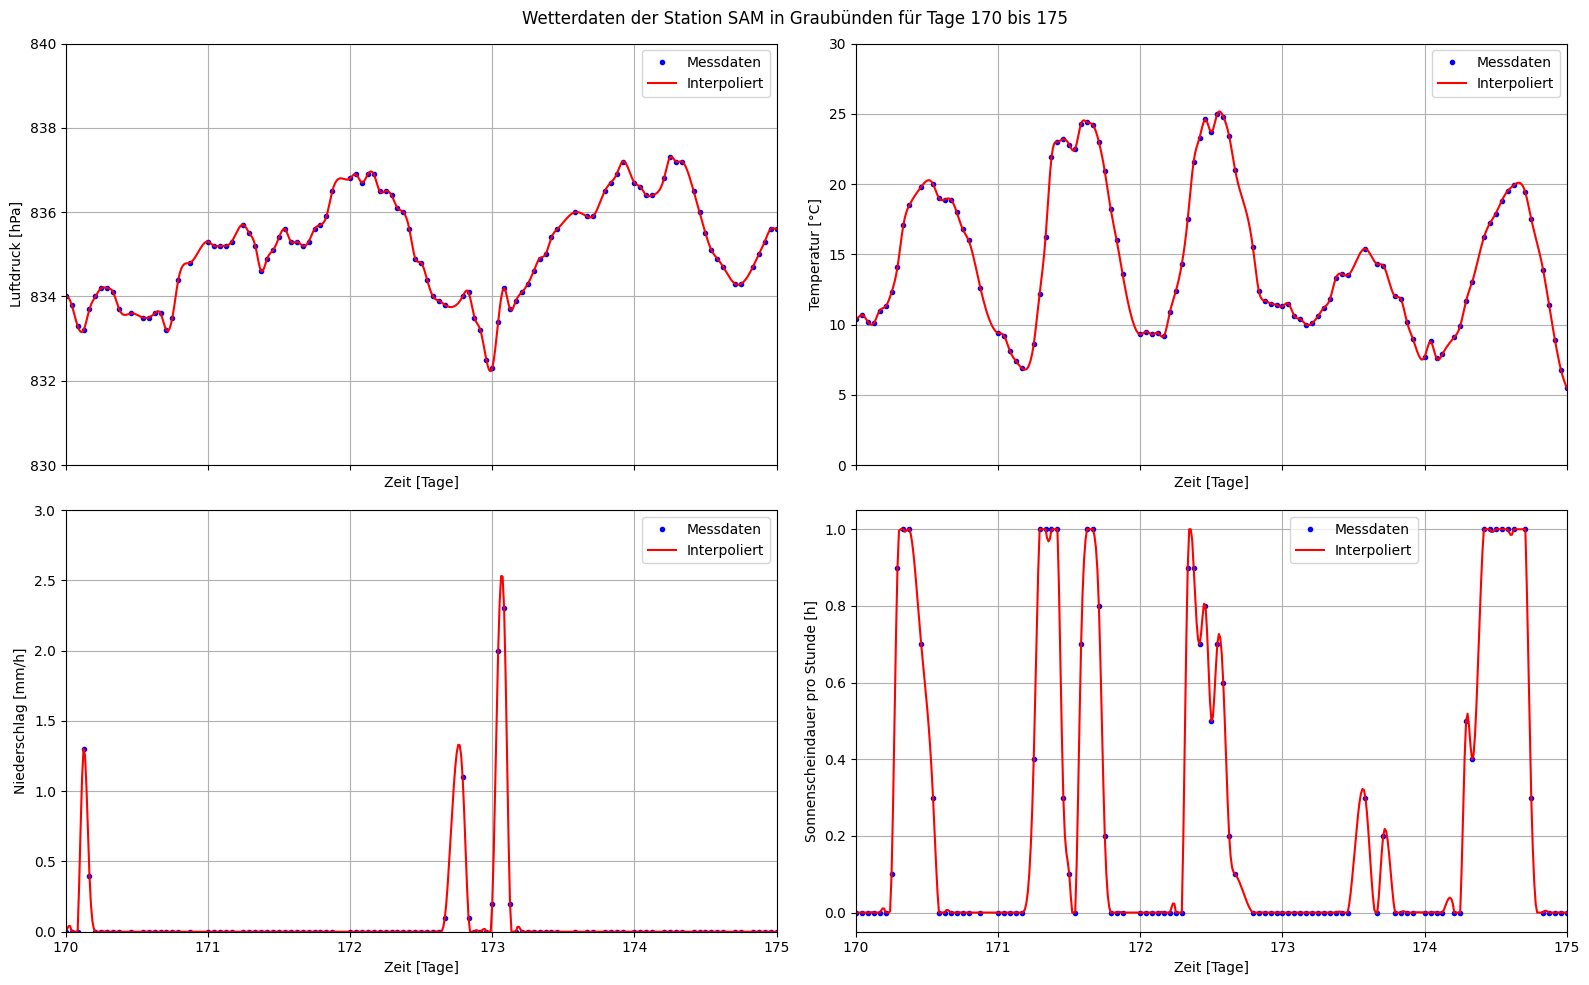

In [12]:
# Darstellungsbereich eingrenzen 
start = 170
ende = 175

# 2x2 Subplots & Array mit Achsen flach machen (flatten)
fig, axes = plt.subplots(2, 2, sharex=True, figsize=(16, 10))
ax0, ax1, ax2, ax3 = axes.flatten()

# Darstellung (Luftdruck)
ax0.plot(time_days, prestah0, color = "blue", marker = ".", linestyle = "None", label = "Messdaten")
ax0.plot(time_full, luftdruck_interp_y, color = "red", label = "Interpoliert")
ax0.set_ylabel("Luftdruck [hPa]")
ax0.set_xlabel("Zeit [Tage]")
ax0.set_ylim(830, 840) # Luftdruckbereich angepasst für Tage 170 bis 175
ax0.set_xlim(start, ende)
ax0.grid()
ax0.legend()

# Darstellung (Temperatur)
ax1.plot(time_days, tre200h0, color = "blue", marker = ".", linestyle = "None", label = "Messdaten")
ax1.plot(time_full, temp_interp_y, color = "red", label = "Interpoliert")
ax1.set_ylabel("Temperatur [°C]")
ax1.set_xlabel("Zeit [Tage]")
ax1.set_ylim(0, 30) # Temperaturbereich angepasst für Tage 170 bis 175
ax1.set_xlim(start, ende)
ax1.grid()
ax1.legend()

# Darstellung (Niederschlag)
ax2.plot(time_days, rre150h0, color = "blue", marker = ".", linestyle = "None", label = "Messdaten")
ax2.plot(time_full, niederschlag_interp_y, color = "red", label = "Interpoliert")
ax2.set_ylabel("Niederschlag [mm/h]")
ax2.set_ylim(0, 3) # Niederschlagsbereich angepasst für Tage 170 bis 175
ax2.set_xlabel("Zeit [Tage]")
ax2.set_xlim(start, ende)
ax2.grid()
ax2.legend()

# Darstelluhng (Sonnenscheindauer)
ax3.plot(time_days, su2000h0, color = "blue", marker = ".", linestyle = "None", label = "Messdaten")
ax3.plot(time_full, sonnenschein_interp_y, color = "red", label = "Interpoliert")
ax3.set_ylabel("Sonnenscheindauer pro Stunde [h]")
ax3.set_xlabel("Zeit [Tage]")
ax3.set_xlim(start, ende)
ax3.grid()
ax3.legend(loc="upper right", bbox_to_anchor=(0.8, 1.0))

plt.suptitle(f"Wetterdaten der Station SAM in Graubünden für Tage {start} bis {ende}")
plt.tight_layout()
plt.show()

Zur Überprüfung der Interpolationsqualität wurden Messwerte und interpolierte Werte für alle vier Messgrößen gemeinsam dargestellt:

- Luftdruck
- Temperatur
- Niederschlag
- Sonnenscheindauer

Dazu wurden fünftägige Ausschnitte gewählt, in denen sowohl Regen als auch Sonnenschein auftraten, um die Dynamik in den Daten sichtbar zu machen.

Die originalen Messwerte sind als blaue Punkte und die interpolierten Werte als rote Linien dargestellt.  
Durch diese grafische Gegenüberstellung kann die Qualität der Interpolation visuell überprüft und die physikalische Plausibilität sichergestellt werden.

Funfact: Der starke Wechsel des Luftdrucks zwischen den Tagen 172 und 174 und der auftretende Niederschlag sind eine schöne grafische Darstellung einer vorbeiziehenden Gewitterfront mit Regen am frühen Morgen.

#### Zusatz:  Visualisierung der viertelstündlichen Interpolation

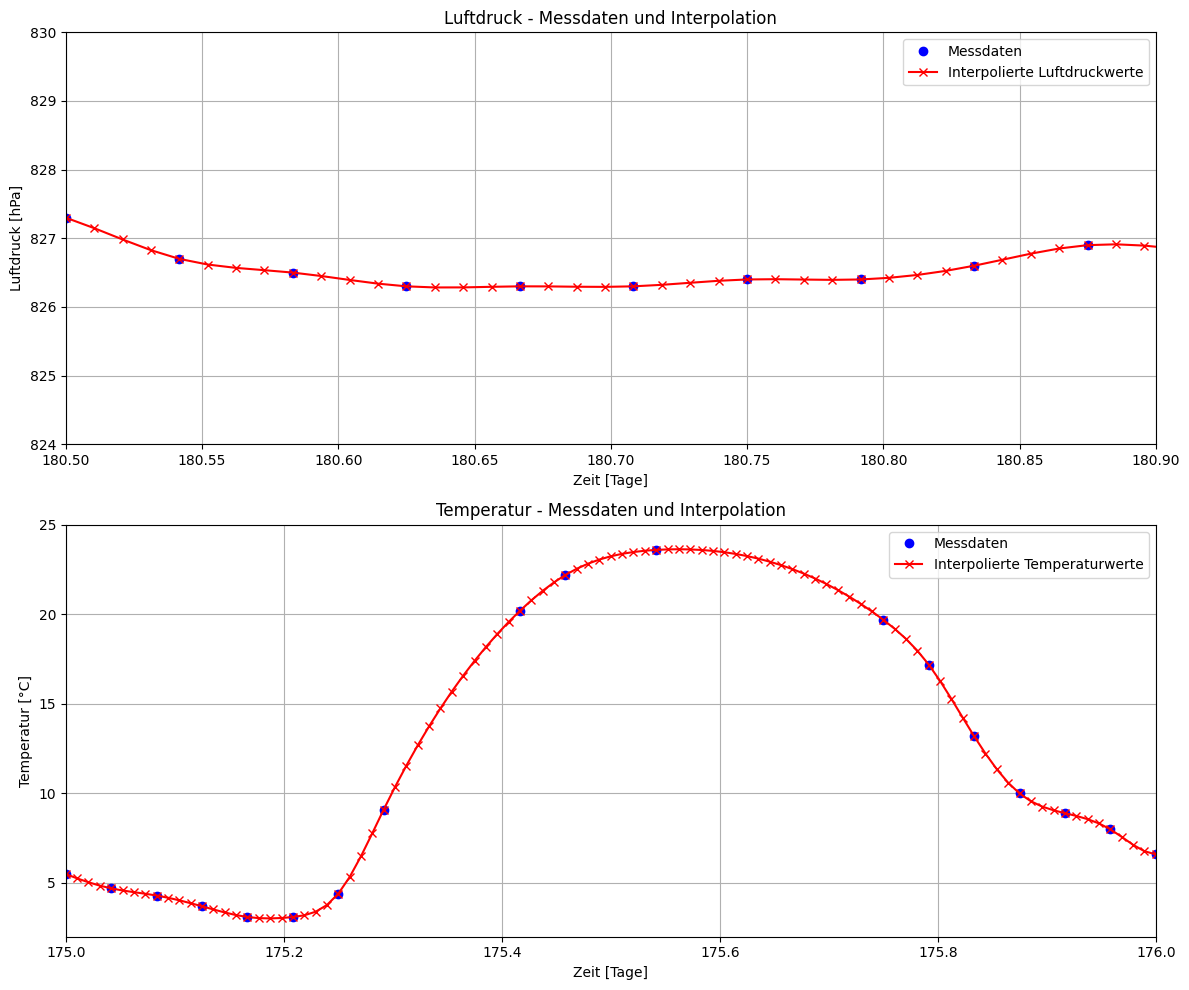

In [13]:
# Visualisierung der Luftdruck- und Temperaturdaten für Viertelstunden-Interpolation

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))  

# Darstellung Luftdruck 
ax1.plot(time_days, prestah0, "ob", label="Messdaten")
ax1.plot(time_full, luftdruck_interp_y, "-xr", label="Interpolierte Luftdruckwerte")
ax1.set_xlim(180.5, 180.9)
ax1.set_ylim(824, 830)
ax1.set_xlabel("Zeit [Tage]")
ax1.set_ylabel("Luftdruck [hPa]")
ax1.set_title("Luftdruck - Messdaten und Interpolation")
ax1.grid()
ax1.legend()

# Darstellung Temperatur 
ax2.plot(time_days, tre200h0, "ob", label="Messdaten")
ax2.plot(time_full, temp_interp_y, "-xr", label="Interpolierte Temperaturwerte")  
ax2.set_xlim(175, 176)
ax2.set_ylim(2, 25)
ax2.set_xlabel("Zeit [Tage]")
ax2.set_ylabel("Temperatur [°C]")
ax2.set_title("Temperatur - Messdaten und Interpolation")
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.show()

Zur Validierung der interpolierten Messreihen wurden sowohl der Luftdruck als auch die Temperatur grafisch dargestellt.  
Dabei wurden jeweils kurze Zeitfenster gewählt, in denen Veränderungen gut sichtbar sind:

- **Luftdruck**: Zeitraum von 180.5 bis 180.9 Tagen
- **Temperatur**: Zeitraum von 175 bis 176 Tagen

In den Plots sind:
- Die **originalen Messwerte** als blaue Punkte dargestellt.
- Die **interpolierten Werte** als rote Linien mit Markierungen dargestellt.

Diese Gegenüberstellung zeigt, dass die Interpolation auf der vollständigen Viertelstunden-Zeitachse plausibel und konsistent mit den vorhandenen Messwerten verläuft.

### 4. Nullstellen der Temperatur bestimmen

Wählt einen Zeitraum von ca. einer Woche, in der die Temperatur um Null herum schwankt. 

Bestimmt die Zeitpunkte, an denen die Temperatur den Wert Null hat. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die Temperatur und die Nullstellen zusammen grafisch dar.

Alternativ (und ein wenig schwieriger) könnt ihr auch einen Zeitraum wählen, in der die Temperatur hohe Werte erreicht. Bestimmt dann die Zeitpunkte, an denen die Temperatur einen bestimmten Hitzewert überschreitet, z.B. 30 Grad.

Nullstellen der Temperaturkurve (Temperatur = 0°C):
[0.18920335 0.23910577 1.23230301 1.32535989 1.81840513 2.43304019
 3.0129798  3.52089274 3.65473979 4.29387396 4.80016805 5.5178127
 5.66354298 6.48519171 6.70833333 7.41666667 7.4503509  7.54668021
 7.70078725]


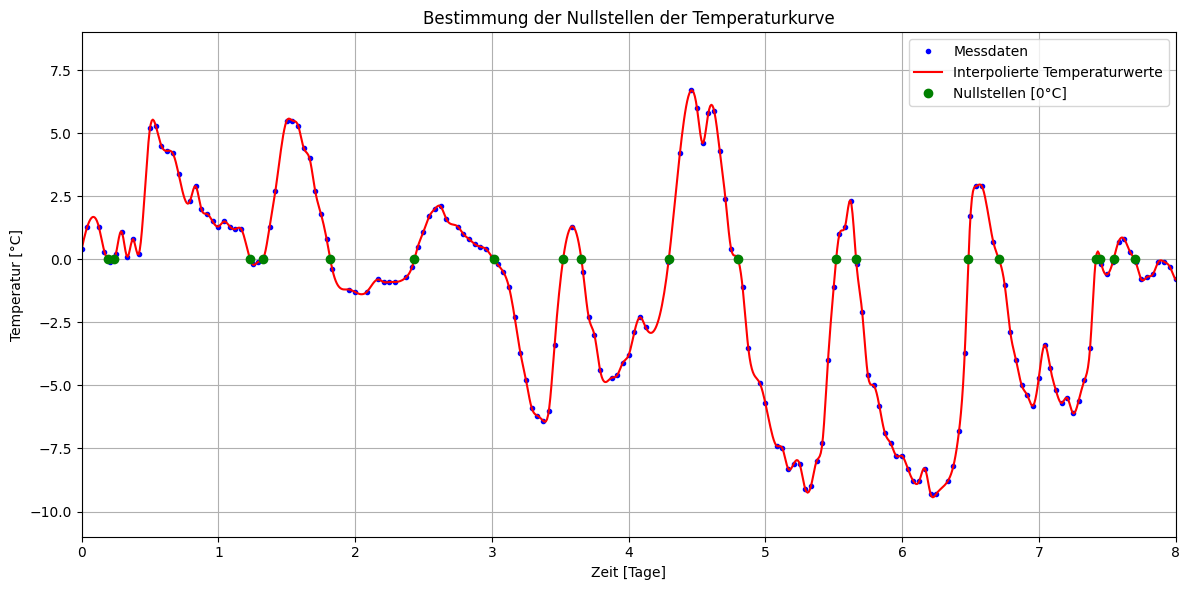

In [14]:
# Interpolation der Temperatur mit kubischem Spline (exakt durch alle Punkte)
tck = interpolate.splrep(time_days, tre200h0, s=0)
temp_spline = interpolate.BSpline(*tck, extrapolate=True)

# Definieren eines feineren Zeitrasters im interessanten Zeitraum (ca. 1 Woche)
new_time = np.linspace(0, 8, 1000)
temp_spline_values = temp_spline(new_time)

# Vorzeichenwechsel identifizieren
sign_changes = np.where(np.diff(np.sign(temp_spline_values)))[0]

# Nullstellen durch Bisektionsmethode bestimmen
x_roots = []
for i in sign_changes:
    a, b = new_time[i], new_time[i+1]
    if temp_spline(a) * temp_spline(b) < 0:
        root = optimize.bisect(temp_spline, a, b)
        x_roots.append(root)
x_roots = np.array(x_roots)

# Ausgabe der exakten Zeitpunkte
print("Nullstellen der Temperaturkurve (Temperatur = 0°C):")
print(x_roots)

# Darstellung der Temperatur und Nullstellen
plt.figure(figsize=(12, 6))
plt.plot(time_days, tre200h0, ".b", label="Messdaten")
plt.plot(new_time, temp_spline_values, "-r", label="Interpolierte Temperaturwerte")
plt.plot(x_roots, np.zeros_like(x_roots), "go", label="Nullstellen [0°C]")
plt.xlabel("Zeit [Tage]")
plt.ylabel("Temperatur [°C]")
plt.title("Bestimmung der Nullstellen der Temperaturkurve")
plt.grid()
plt.xlim(0, 8)
plt.ylim(-11, 9)
plt.legend()
plt.tight_layout()
plt.show()

In dieser Aufgabe wird ein Zeitraum von etwa einer Woche betrachtet (Tag 0 bis Tag 8), in dem die Temperatur um den Wert 0 °C schwankt.  
Ziel ist es, die exakten Zeitpunkte zu bestimmen, an denen die Temperatur die 0-Grad-Grenze über- oder unterschreitet.

Dazu wurde:
- Eine kubische Spline-Interpolation (`s=0`) auf die Temperaturdaten angewendet, um eine glatte Kurve zu erzeugen.
- Ein feineres Zeitraster (1000 Werte zwischen Tag 0 und Tag 8) erstellt, um die interpolierte Kurve exakt zu analysieren.
- Die Nullstellen der Temperaturkurve identifiziert, indem Vorzeichenwechsel detektiert und mithilfe der Bisektionsmethode (`bisect`) präzise bestimmt wurden.

Im Plot sind dargestellt:
- Blaue Punkte: Originale Messdaten der Temperatur
- Rote Linie: Interpolierte Temperaturkurve
- Grüne Kreise: Gefundene Nullstellen bei 0 °C

Zusätzlich werden die genauen Tageszeitpunkte der Nullstellen numerisch ausgegeben.

### 5. Grosse Schwankungen in Temperatur oder Luftdruck finden

Betrachtet entweder die Temperatur oder den Luftdruck übers ganze Jahr. Berechnet die Ableitung der gewählten Variable und stellt diese auch dar, um einen Zeitraum von ca. 1 Woche mit grossen Schwankungen zu finden. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

In der gewählten Woche mit grossen Schwankungen sollen nun die Zeitpunkte bestimmt werden, zu denen die Temperatur bzw. der Luftdruck am stärksten steigt bzw. fällt, also das Maximum und das Minimum der Ableitung.

Um das Maximum/Minimum eines Arrays zu finden, könnt ihr die Funktionen [`np.argmax`](https://numpy.org/doc/stable//reference/generated/numpy.argmax.htm) und [`np.argmin`](https://numpy.org/doc/stable//reference/generated/numpy.argmin.html) verwenden. 

Maximaler Luftdruckwechsel [hPa/h]: 2.3244502595423384
Tag der maximalen Luftdruckänderung: 192.88541666666666
Minimaler Luftdruckwechsel [hPa/h]: -1.797971085195206
Tag der minimalen Luftdruckänderung: 305.40625
Maximaler Temperaturwechsel [°C/h]: 8.761074798087025
Tag der maximalen Temperaturänderung: 330.4375
Minimaler Temperaturwechsel [°C/h]: -5.578082566968475
Tag der minimalen Temperaturänderung: 273.69791666666663


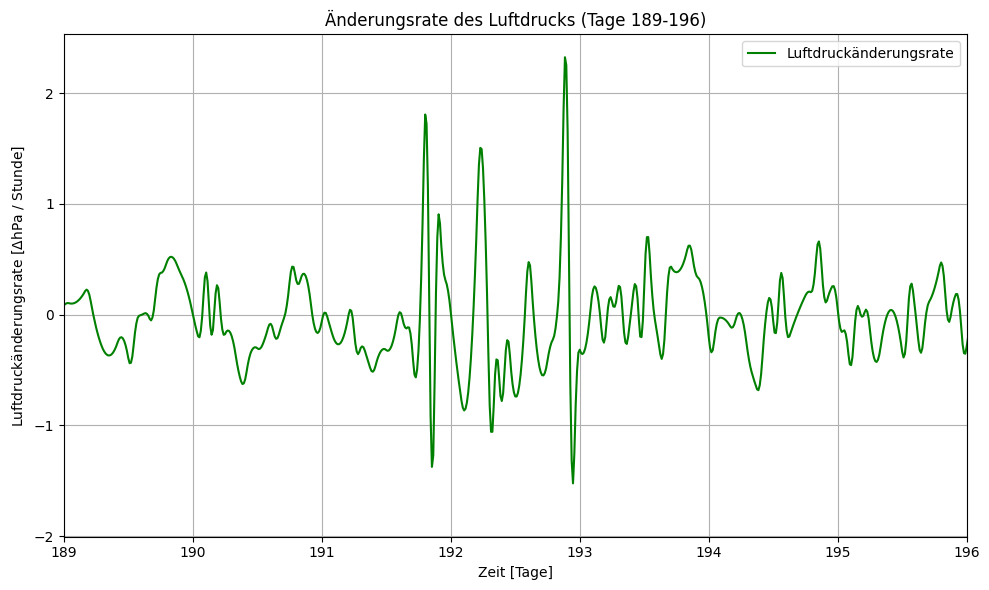

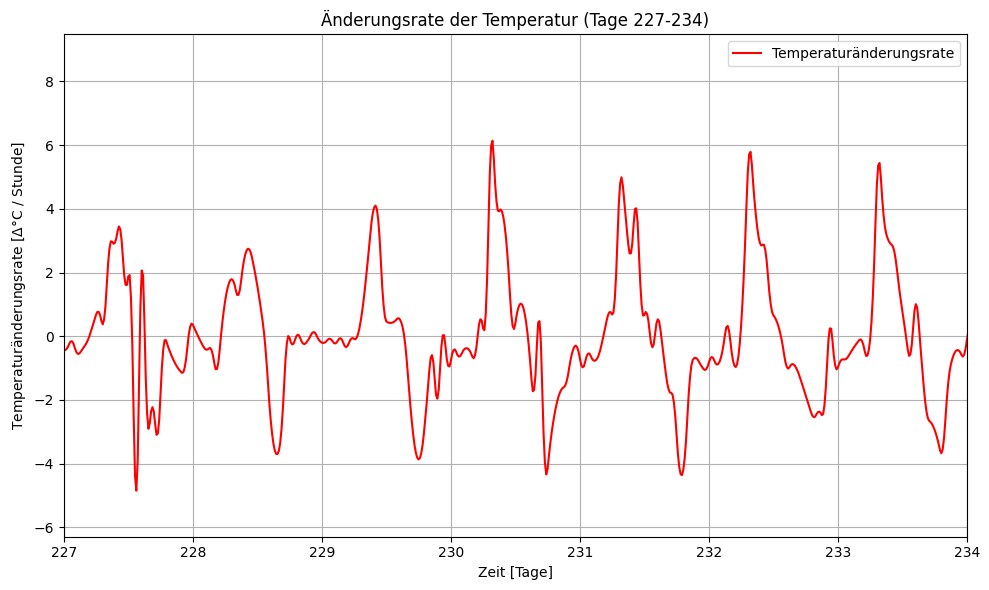

In [15]:
# Derivative erstellen
luftdruck_interp_deriv = luftdruck_interp.derivative()
temp_interp_deriv = temp_interp.derivative()

# Änderungsraten pro Stunde berechnen
luftdruck_interp_deriv_y = luftdruck_interp_deriv(time_full) / 24
temp_interp_deriv_y = temp_interp_deriv(time_full) / 24

# Maxima und Minima Luftdruckänderung
max_presh_change = luftdruck_interp_deriv_y[np.argmax(luftdruck_interp_deriv_y)]
min_presh_change = luftdruck_interp_deriv_y[np.argmin(luftdruck_interp_deriv_y)]

print("Maximaler Luftdruckwechsel [hPa/h]:", max_presh_change)
print("Tag der maximalen Luftdruckänderung:", time_full[np.argmax(luftdruck_interp_deriv_y)])
print("Minimaler Luftdruckwechsel [hPa/h]:", min_presh_change)
print("Tag der minimalen Luftdruckänderung:", time_full[np.argmin(luftdruck_interp_deriv_y)])

# Maxima und Minima Temperaturänderung
max_tmp_change = temp_interp_deriv_y[np.argmax(temp_interp_deriv_y)]
min_tmp_change = temp_interp_deriv_y[np.argmin(temp_interp_deriv_y)]

print("Maximaler Temperaturwechsel [°C/h]:", max_tmp_change)
print("Tag der maximalen Temperaturänderung:", time_full[np.argmax(temp_interp_deriv_y)])
print("Minimaler Temperaturwechsel [°C/h]:", min_tmp_change)
print("Tag der minimalen Temperaturänderung:", time_full[np.argmin(temp_interp_deriv_y)])

# Darstellung Luftdruckänderung
plt.figure(figsize=(10,6))
plt.plot(time_full, luftdruck_interp_deriv_y, color="green", label="Luftdruckänderungsrate")
plt.xlim(189, 196)
plt.xlabel("Zeit [Tage]")
plt.ylabel("Luftdruckänderungsrate [$\\Delta$hPa / Stunde]")
plt.title("Änderungsrate des Luftdrucks (Tage 189-196)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Darstellung Temperaturänderung 
plt.figure(figsize=(10,6))
plt.plot(time_full, temp_interp_deriv_y, color="red", label="Temperaturänderungsrate")
plt.xlim(227, 234)
plt.xlabel("Zeit [Tage]")
plt.ylabel("Temperaturänderungsrate [$\\Delta$°C / Stunde]")
plt.title("Änderungsrate der Temperatur (Tage 227-234)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

Um Zeiträume mit großen Schwankungen zu identifizieren, wurde die Änderungsrate (erste Ableitung) der Temperatur und des Luftdrucks bestimmt.  
Dazu wurde auf die zuvor erstellten Interpolationsfunktionen (Splines) zurückgegriffen.

Die Änderungsraten wurden in Einheiten pro Stunde umgerechnet (ursprünglich auf Tagesbasis) und grafisch über das Jahr dargestellt.

Für die detaillierte Analyse wurden zwei Zeitfenster ausgewählt:
- **Luftdruck**: Zeitraum von Tag 189 bis 196
- **Temperatur**: Zeitraum von Tag 227 bis 234

In beiden Zeitfenstern wurden mit `np.argmax()` und `np.argmin()` die Tage bestimmt, an denen die stärkste Zunahme bzw. der stärkste Abfall auftrat.

In den Plots sind die Änderungsraten klar dargestellt und erlauben die präzise Identifikation der dynamischsten Phasen im Verlauf des Jahres.


### 6. Mittelwerte berechnen

Wählt eine der Messgrössen aus und berechnet den Mittelwert über das ganze Jahr und den Mittelwert pro Monat (1 Monat = 1/12 des Jahres). Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die eigentliche Variable und die Mittelwerte zusammen grafisch dar.

Die Mittelung soll mithilfe der Integration über die Interpolationsfunktion aus Schritt 2 berechnet werden.

Bei der Integration kann es Warnungen geben, da die Interpolationsfunktionen teils stark schwanken. Es kann hilfreich sein, mit dem Parameter `limit` die Anzahl Subintervalle zu erhöhen. Probiert aus, ab wann sich das Resultat nicht mehr gross ändert.

*Empfehlungen:* 
- Implementiert dies zuerst für die Temperatur, da diese am einfachsten zu interpretieren ist. Dann könnt ihr immer noch die anderen Messgrössen betrachten.
- Beginnt mit dem Mittelwert über das ganze Jahr, dann verallgemeinert für ein beliebiges Zeitintervall und iteriert schliesslich über die Monate.

/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/2536981477.py:2: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean_year_temp = quad(temp_interp, 0, 365, limit=10000)[0] / 365
/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/2536981477.py:12: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean = quad(temp_interp, start, end, limit=10000)[0] / (end - start)


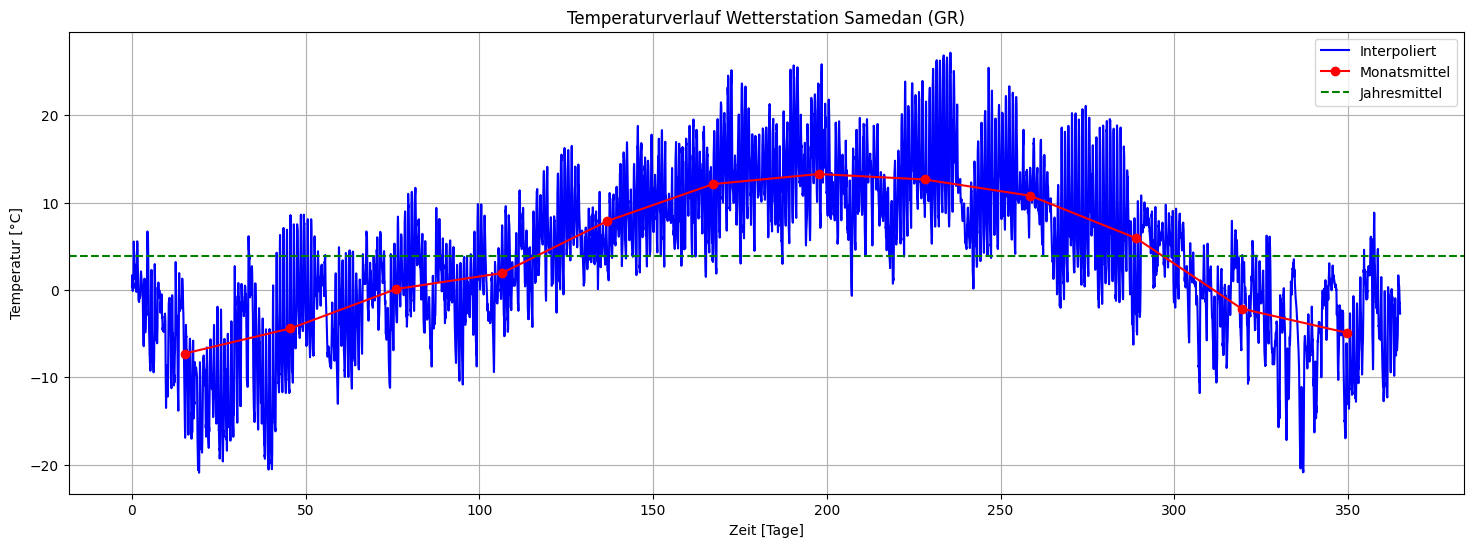

In [16]:
# Mittelwert Temperatur über das Jahr
mean_year_temp = quad(temp_interp, 0, 365, limit=10000)[0] / 365

# Mittelwerte pro Monat
month_range = 365 / 12
start = 0
mean_month_temp = []
months = []

for month in range(1, 13):
    end = start + month_range
    mean = quad(temp_interp, start, end, limit=10000)[0] / (end - start)
    months.append(start + month_range / 2)
    mean_month_temp.append(mean)
    start = end

mean_month_temp = np.array(mean_month_temp)
months = np.array(months)

# Darstellung
plt.figure(figsize=(18, 6))
plt.plot(time_full, temp_interp_y, linestyle='-', color="b", label="Interpoliert")
plt.plot(months, mean_month_temp, linestyle='-', marker="o", color="r", label="Monatsmittel")
plt.axhline(mean_year_temp, linestyle='--', color="g", label="Jahresmittel")
plt.title("Temperaturverlauf Wetterstation Samedan (GR)")
plt.ylabel("Temperatur [°C]")
plt.xlabel("Zeit [Tage]")
plt.grid()
plt.legend()
plt.show()




/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/3124476196.py:2: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean_year_pressure = quad(luftdruck_interp, 0, 365, limit=10000)[0] / 365 # Integral der Luftdruckkurve
/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/3124476196.py:12: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean = quad(luftdruck_interp, start, end, limit=10000)[0] / (end - start)


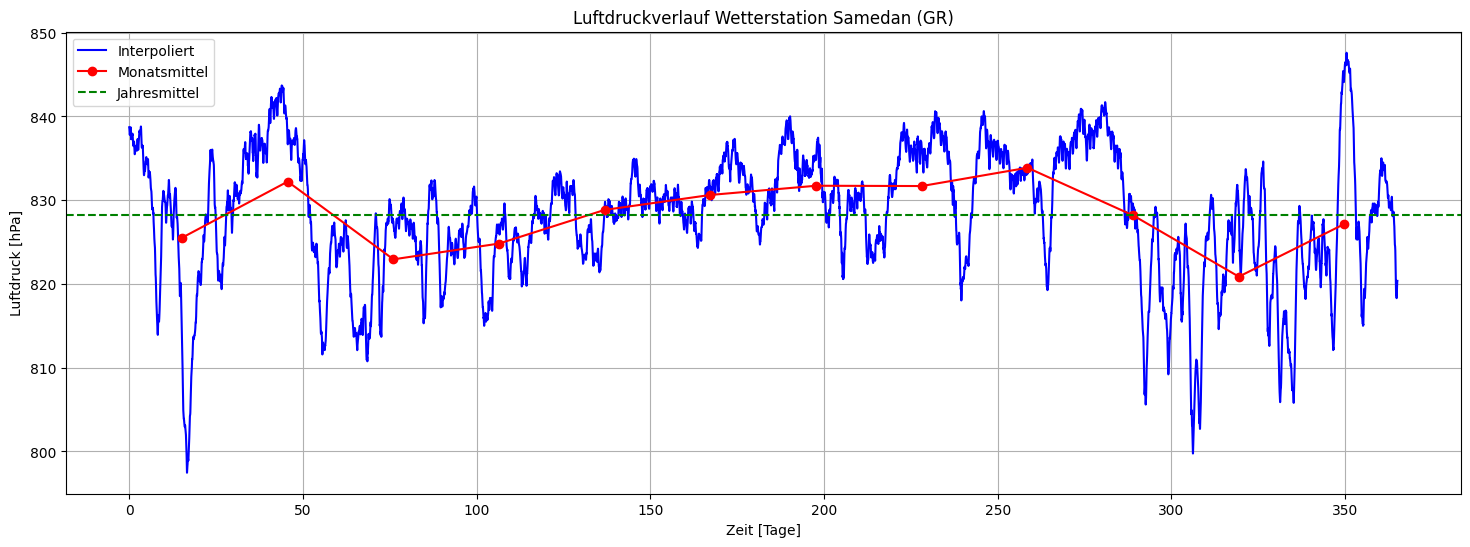

In [17]:
# Mittelwert Luftdruck über das Jahr
mean_year_pressure = quad(luftdruck_interp, 0, 365, limit=10000)[0] / 365 # Integral der Luftdruckkurve

# Mittelwerte Luftdruck pro Monat
month_range = 365 / 12
start = 0
mean_month_pressure = []
months = []

for month in range(1, 13):
    end = start + month_range
    mean = quad(luftdruck_interp, start, end, limit=10000)[0] / (end - start)
    months.append(start + month_range / 2)
    mean_month_pressure.append(mean)
    start = end

mean_month_pressure = np.array(mean_month_pressure)
months = np.array(months)

# Darstellung Luftdruck
plt.figure(figsize=(18, 6))
plt.plot(time_full, luftdruck_interp_y, linestyle='-', color="b", label="Interpoliert")
plt.plot(months, mean_month_pressure, linestyle='-', marker="o", color="r", label="Monatsmittel")
plt.axhline(mean_year_pressure, linestyle='--', color="g", label="Jahresmittel")
plt.title("Luftdruckverlauf Wetterstation Samedan (GR)")
plt.ylabel("Luftdruck [hPa]")
plt.xlabel("Zeit [Tage]")
plt.grid()
plt.legend()
plt.show()


/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/764679458.py:2: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean_year_rain = quad(niederschlag_interp, 0, 365, limit=10000)[0] / 365
/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/764679458.py:12: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean = quad(niederschlag_interp, start, end, limit=10000)[0] / (end - start)


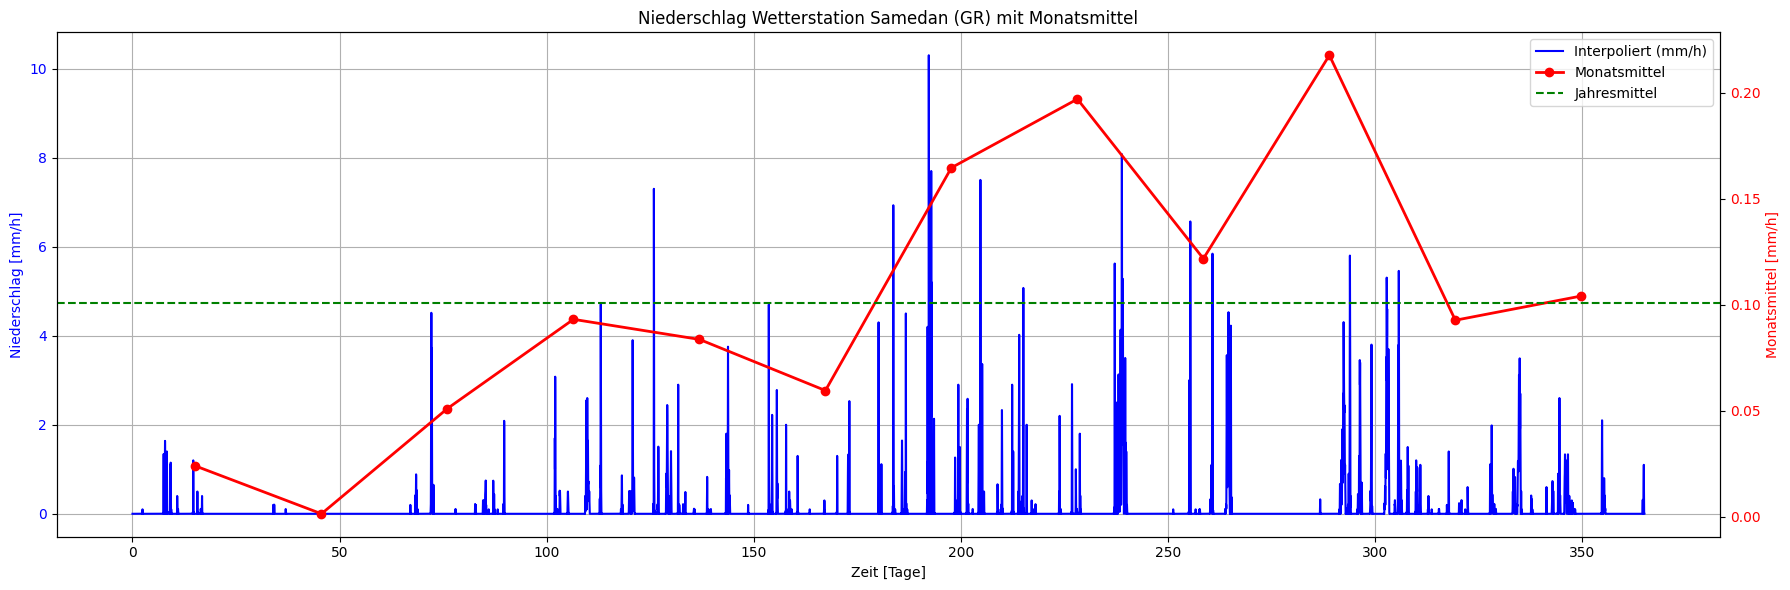

In [18]:

# Mittelwert Niederschlag über das Jahr
mean_year_rain = quad(niederschlag_interp, 0, 365, limit=10000)[0] / 365

# Mittelwerte Niederschlag pro Monat
month_range = 365 / 12
start = 0
mean_month_rain = []
months = []

for month in range(1, 13):
    end = start + month_range
    mean = quad(niederschlag_interp, start, end, limit=10000)[0] / (end - start)
    months.append(start + month_range / 2)
    mean_month_rain.append(mean)
    start = end

mean_month_rain = np.array(mean_month_rain)
months = np.array(months)


# Darstellung Niederschlag mit zwei Y-Achsen
fig, ax1 = plt.subplots(figsize=(18, 6))

# Erste Achse: Interpolierter Niederschlag
ax1.plot(time_full, niederschlag_interp_y, linestyle='-', color="b", label="Interpoliert (mm/h)")
ax1.set_ylabel("Niederschlag [mm/h]", color="b")
ax1.set_xlabel("Zeit [Tage]")
ax1.tick_params(axis='y', labelcolor="b")
ax1.grid()

# Zweite Achse: Monatsmittel
ax2 = ax1.twinx()
ax2.plot(months, mean_month_rain, linestyle='-', marker="o", color="r", label="Monatsmittel", linewidth=2)
ax2.axhline(mean_year_rain, linestyle='--', color="g", label="Jahresmittel")
ax2.set_ylabel("Monatsmittel [mm/h]", color="r")
ax2.tick_params(axis='y', labelcolor="r")

# Legenden kombinieren
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

plt.title("Niederschlag Wetterstation Samedan (GR) mit Monatsmittel")
plt.tight_layout()
plt.show()


/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/1709376290.py:2: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean_year_sun = quad(sonnenschein_interp, 0, 365, limit=10000)[0] / 365
/var/folders/w6/gw26y3191fn3gp_3kdqd8dyh0000gq/T/ipykernel_42857/1709376290.py:12: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  mean = quad(sonnenschein_interp, start, end, limit=10000)[0] / (end - start)


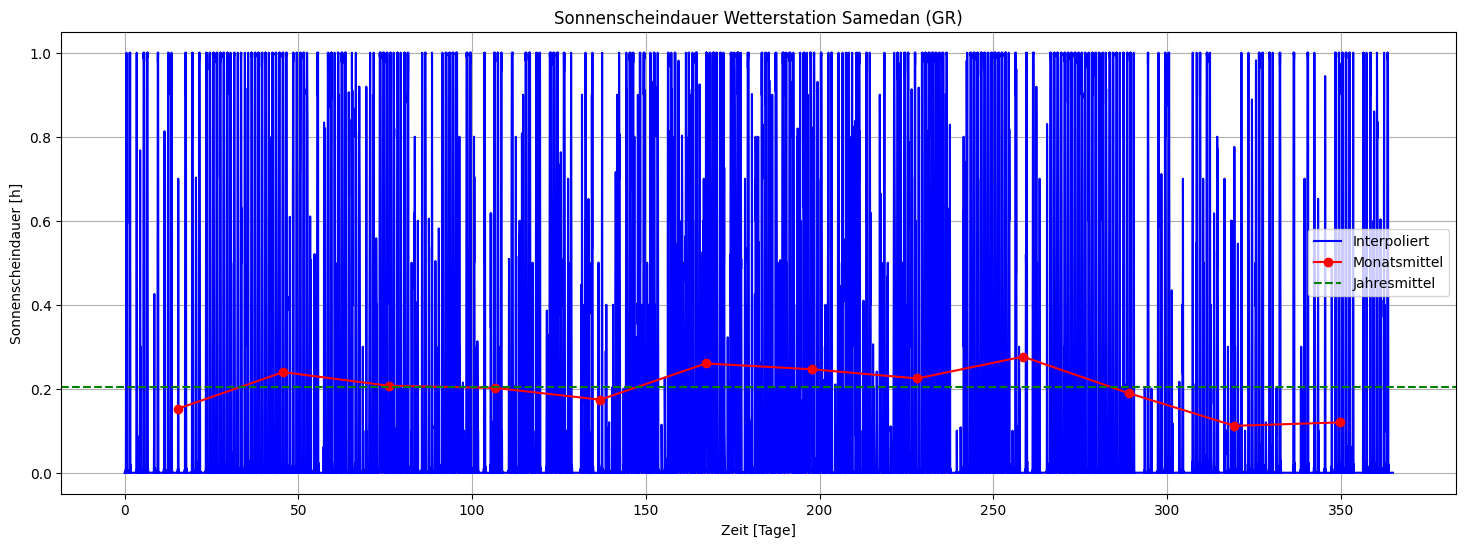

In [19]:
# Mittelwert Sonnenscheindauer über das Jahr
mean_year_sun = quad(sonnenschein_interp, 0, 365, limit=10000)[0] / 365

# Mittelwerte Sonnenscheindauer pro Monat
month_range = 365 / 12
start = 0
mean_month_sun = []
months = []

for month in range(1, 13):
    end = start + month_range
    mean = quad(sonnenschein_interp, start, end, limit=10000)[0] / (end - start)
    months.append(start + month_range / 2)
    mean_month_sun.append(mean)
    start = end

mean_month_sun = np.array(mean_month_sun)
months = np.array(months)

# Darstellung Sonnenscheindauer
plt.figure(figsize=(18, 6))
plt.plot(time_full, sonnenschein_interp_y, linestyle='-', color="b", label="Interpoliert")
plt.plot(months, mean_month_sun, linestyle='-', marker="o", color="r", label="Monatsmittel")
plt.axhline(mean_year_sun, linestyle='--', color="g", label="Jahresmittel")
plt.title("Sonnenscheindauer Wetterstation Samedan (GR)")
plt.ylabel("Sonnenscheindauer [h]")
plt.xlabel("Zeit [Tage]")
plt.grid()
plt.legend()
plt.show()


Um die Mittelwerte zu berechnen wurden die Flächen unter der jeweiligen Interpolationskurve mithilfe der numerischen Integration (`quad()` aus `scipy.integrate`) bestimmt.  
Für den Jahresmittelwert wurde die Fläche über den gesamten Jahreszeitraum (0 bis 365 Tage) integriert und anschliessend durch 365 geteilt.  
Die Monatsmittelwerte haben wir berechnet, indem wir das Jahr in 12 gleich grosse Intervalle aufgeteilt und für jedes Intervall separat integriert haben.

Um die Genauigkeit der Integration zu erhöhen, haben wir den Parameter `limit` auf 10'000 gesetzt, was eine feinere Unterteilung der Intervalle ermöglicht.

Zur besseren Visualisierung haben wir die interpolierte Kurve sowie die Monatsmittelpunkte grafisch dargestellt.  
Die Monatsmittelwerte sind durch rote Markierungen und Linien hervorgehoben, der Jahresmittelwert als grüne gestrichelte Linie eingezeichnet.

Zusätzlich haben wir die Auswertung auch auf die Messgrössen Niederschlag und Sonnenscheindauer erweitert, obwohl dies nicht explizit Teil der Aufgabenstellung war.  
Dies erlaubt eine umfassendere Analyse der saisonalen Entwicklungen an der Wetterstation Samedan.


### 7. Glättung (Gleitendes Mittel) bestimmen

Nehmt die gleiche Messgrösse wie in Schritt 6 und berechnet das gleitende Mittel über das ganze Jahr. Dazu soll die Faltung mit einer symmetrischen Rechteckfunktion verwendet werden. Die Fensterbreite (Breite des Rechtecks) soll ein Parameter sein, den ihr variieren könnt.

Stellt die Messgrösse und das gleitende Mittel mit Fensterbreite = 7 Tage zusammen dar. Optional könnt ihr dazu auch noch das gleitende Mittel mit Fensterbreite = 14 und/oder 28 Tage darstellen.

Entscheidet selbst, ob ihr die kontinuierliche Faltung (Integration) oder die diskrete Faltung (Matrixmultiplikation) benutzt. 

*Vorsicht:* Die kontinuierliche Faltung (Integration) ist rechenintensiv. Berechnet also zuerst das gleitende Mittel an wenigen Zeitpunkten über das ganze Jahr, z.B. 100, und erhöht dann die Anzahl Zeitpunkte vorsichtig.

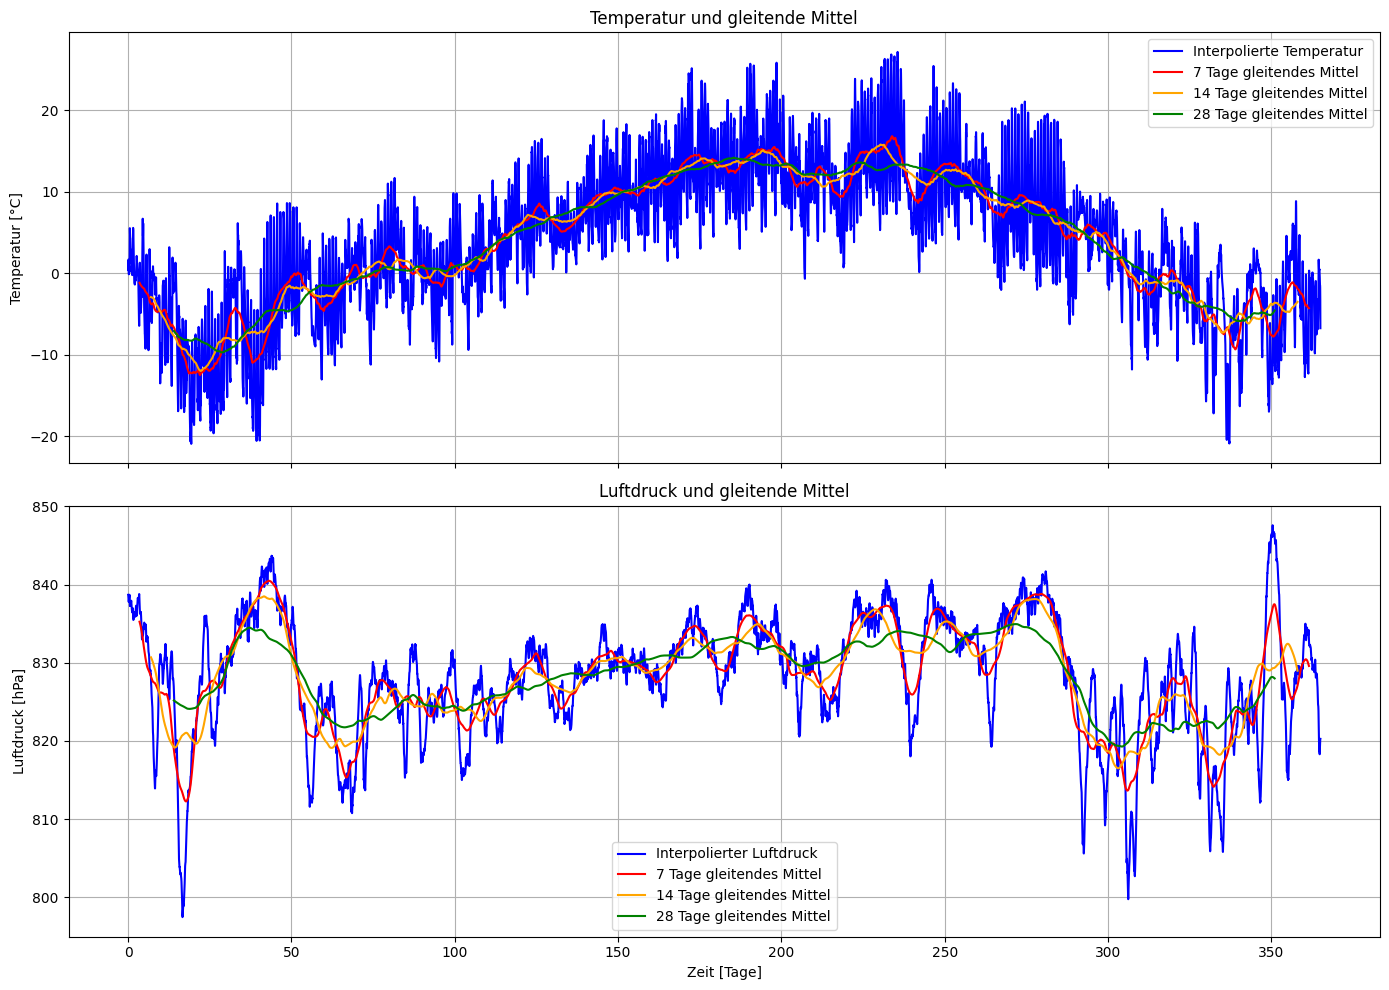

In [ ]:
# Temperatur- und Luftdruck-Spline erneut sauber erstellen
temp_spline_func = interpolate.UnivariateSpline(time_days, tre200h0, s=0)
pres_spline_func = interpolate.UnivariateSpline(time_days, prestah0, s=0)

# Temperatur und Luftdruck auf feiner Zeitachse auswerten
temp_values_fine = temp_spline_func(time_full)
pres_values_fine = pres_spline_func(time_full)

# Funktion für gleitendes Mittel mit diskreter Faltung
def moving_average(values, window_size):
    """Berechnet das gleitende Mittel mit diskreter Faltung."""
    window = np.ones(window_size) / window_size
    return np.convolve(values, window, mode='valid')

# Fenstergrößen (in Punkten) berechnen
points_per_day = 24 * 4  # 4 Werte pro Stunde
window_7d = 7 * points_per_day
window_14d = 14 * points_per_day
window_28d = 28 * points_per_day

# Gleitende Mittel berechnen
temp_ma_7d = moving_average(temp_values_fine, window_7d)
temp_ma_14d = moving_average(temp_values_fine, window_14d)
temp_ma_28d = moving_average(temp_values_fine, window_28d)

pres_ma_7d = moving_average(pres_values_fine, window_7d)
pres_ma_14d = moving_average(pres_values_fine, window_14d)
pres_ma_28d = moving_average(pres_values_fine, window_28d)

# Angepasste Zeitachsen für gleitende Mittel berechnen
time_valid_7d = time_full[(window_7d - 1)//2 : -(window_7d // 2)]
time_valid_14d = time_full[(window_14d - 1)//2 : -(window_14d // 2)]
time_valid_28d = time_full[(window_28d - 1)//2 : -(window_28d // 2)]

# Visualisierung

fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Darstellung Temperatur
axs[0].plot(time_full, temp_values_fine, color='blue', label='Interpolierte Temperatur')
axs[0].plot(time_valid_7d, temp_ma_7d, color='red', label='7 Tage gleitendes Mittel')
axs[0].plot(time_valid_14d, temp_ma_14d, color='orange', label='14 Tage gleitendes Mittel')
axs[0].plot(time_valid_28d, temp_ma_28d, color='green', label='28 Tage gleitendes Mittel')
axs[0].set_ylabel("Temperatur [°C]")
axs[0].set_title("Temperatur und gleitendes Mittel")
axs[0].legend()
axs[0].grid()

# Darstellung Luftdruck 
axs[1].plot(time_full, pres_values_fine, color='blue', label='Interpolierter Luftdruck')
axs[1].plot(time_valid_7d, pres_ma_7d, color='red', label='7 Tage gleitendes Mittel')
axs[1].plot(time_valid_14d, pres_ma_14d, color='orange', label='14 Tage gleitendes Mittel')
axs[1].plot(time_valid_28d, pres_ma_28d, color='green', label='28 Tage gleitendes Mittel')
axs[1].set_ylabel("Luftdruck [hPa]")
axs[1].set_xlabel("Zeit [Tage]")
axs[1].set_title("Luftdruck und gleitendes Mittel")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()


Zur Glättung der Temperatur- und Luftdruckdaten haben wir das gleitende Mittel mithilfe einer diskreten Faltung mit einer symmetrischen Rechteckfunktion bestimmt.  
Als Ausgangsbasis dienten die interpolierten Werte auf der fein aufgelösten Zeitachse aus Schritt 2.

Für die Faltung haben wir eine normalisierte Rechteckfunktion verwendet und verschiedene Fensterbreiten untersucht.  
Konkret wurden Fensterbreiten von 7, 14 und 28 Tagen gewählt, um den Einfluss der Glättung auf den Temperatur- und Luftdruckverlauf zu analysieren.

Wir haben uns bewusst für die diskrete Faltung entschieden, da sie numerisch stabil, sehr effizient und bei unserer feinen Zeitauflösung präzise genug ist.  
Zudem ermöglicht die diskrete Methode eine flexible Anpassung der Fenstergrössen und vermeidet die hohen Rechenaufwände sowie potenzielle Genauigkeitsprobleme, die bei einer kontinuierlichen Faltung auftreten könnten.

Die Faltung erfolgte über die `np.convolve`-Funktion, wodurch ein diskretes gleitendes Mittel berechnet werden konnte.  
Um die korrekte Zuordnung der Zeitachsen sicherzustellen, haben wir die Zeitvektoren jeweils um die halbe Fensterbreite angepasst.

In der grafischen Darstellung sind sowohl die ursprünglichen interpolierten Messwerte (blaue Linie) als auch die geglätteten Kurven (rote, orange und grüne Linien) dargestellt.  
Die Visualisierung zeigt anschaulich, wie sich durch zunehmende Fensterbreite die Schwankungen der Kurven verringern und die saisonalen Trends deutlicher hervortreten.


### Zusammenfassung

Im Rahmen dieses Projekts haben wir Wetterdaten der Station Samedan (Graubünden) umfassend analysiert.

Zu Beginn wurden die Rohdaten eingelesen, auf die relevanten Messgrössen reduziert und in handhabbare Arrays umgewandelt.  
Darauf aufbauend erfolgte eine Interpolation der Messwerte mit kubischen Splines, um eine kontinuierliche Zeitreihe mit viertelstündlicher Auflösung zu erzeugen.

Zur Überprüfung der Interpolationsqualität wurden Teilabschnitte der Messdaten grafisch dargestellt und ausgewertet.  
Anschliessend haben wir verschiedene analytische Aufgaben bearbeitet:
- Bestimmung von Nullstellen der Temperaturkurve
- Identifikation von Zeiträumen mit grossen Schwankungen durch Ableitung der Messgrössen
- Berechnung von Jahres- und Monatsmittelwerten mithilfe numerischer Integration
- Analyse und Darstellung geglätteter Zeitreihen über verschiedene Fensterbreiten mittels diskreter Faltung

Alle Berechnungen und Visualisierungen basieren konsequent auf den interpolierten Daten und wurden in einem konsistenten, nachvollziehbaren Stil umgesetzt.  
Zusatzanalysen wie Monatsmittel von Niederschlag und Sonnenscheindauer erweitern die Aufgabenstellung sinnvoll und runden das Projekt ab.

Durch die strukturierte Bearbeitung der Aufgaben konnten wir sowohl wichtige numerische Verfahren als auch relevante Aspekte der Wetterdatenanalyse praxisnah anwenden.
